In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
from pathlib import Path
#from sklearn.cross_decomposition import CCA
from mvlearn.embed import CCA
from scipy.stats import pearsonr 
from scipy import stats
from typing import List, Tuple, Optional
import numpy as np


###############################################################################
# Paths & constants
###############################################################################
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow")

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

OUT_TRIALS  = Path("trial_level_cca_fixedlag.csv")
OUT_SUBJECT = Path("subject_best_lag.csv")

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SHIFTS = np.arange(-100, 101)      # ±1 s at 100 Hz → samples
WIN_OFFSET1 = 200                  # discard first 200 ms
WIN_OFFSET2 = 110                  # discard last 110 ms

###############################################################################
# Helper functions
###############################################################################

def normalise_eeg(x: np.ndarray) -> np.ndarray:
    """Centre each channel and scale so Σ x² = 1 over time×channels."""
    x = x - x.mean(axis=0, keepdims=True)
    scale = np.sqrt(np.mean(x**2))
    return x / scale


def cca_corr(eeg: np.ndarray, pupil: np.ndarray) -> float:
    """Canonical correlation (single component)."""
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(eeg, pupil)
    u, v = cca.transform(eeg, pupil)
    return float(np.corrcoef(u[:, 0], v[:, 0])[0, 1])

In [2]:
def load_all_trials(
        sub: int,
        eeg_root: Path = EEG_ROOT,
        pupil_root: Path = PUPIL_ROOT,
        min_len: int = 40,
        max_len_diff: int = 30,
) -> list[tuple[np.ndarray, np.ndarray, dict]]:
    """
    Load *all* valid EEG-pupil trial pairs for one subject.

    Parameters
    ----------
    sub : int
        Numeric subject ID (e.g. 42).
    eeg_root, pupil_root : Path
        Roots of the pre-processed EEG and pupil folders.
    min_len : int
        Minimum number of samples a pupil trace must have to be accepted.
    max_len_diff : int
        Reject trial if |len(pupil)-len(eeg)| exceeds this.
    Returns
    -------
    trials : list of (eeg, pupil_z, meta)
        * eeg        - (T × n_channels) float64, already centred/scaled
        * pupil_z    - (T × 1) float64, per-trial z-scored
        * meta       - dict with subject/condition/load/epoch
    """
    trials = []
    sub_tag = f"sub-{sub:03d}"
    eeg_sub  = eeg_root   / sub_tag
    pupil_sub = pupil_root / sub_tag

    if not eeg_sub.exists():
        print(f"{sub_tag}: EEG folder missing - skipped")
        return trials

    # iterate condition (“control” / “memory”) and load (“05” / “09” / “13”)
    for cond_path in sorted(eeg_sub.iterdir()):
        if not cond_path.is_dir():
            continue
        for load_path in sorted(cond_path.iterdir()):
            if not load_path.is_dir():
                continue

            # matching pupil directory
            pupil_path = pupil_sub / cond_path.name / load_path.name
            if not pupil_path.exists():
                continue

            eeg_epochs   = sorted(load_path.glob("trial_*.csv"))
            pupil_epochs = sorted(pupil_path.glob("trial_*.csv"))
            common = {f.name for f in eeg_epochs} & {f.name for f in pupil_epochs}
            if not common:
                continue

            for fname in sorted(common):
                eeg_df = pd.read_csv(load_path / fname, comment="#", index_col=0)
                pupil_df = pd.read_csv(pupil_path / fname, comment="#", skiprows=1,
                                       names=["time", "diameter_z"], index_col=0)

                eeg   = eeg_df.values.astype(float)
                pupil = pupil_df["diameter_z"].values.astype(float)

                # basic validity checks
                if len(pupil) < min_len or abs(len(pupil) - len(eeg)) > max_len_diff:
                    continue

                # normalise signals ----------------------------------------
                eeg_norm = normalise_eeg(eeg)           # your helper from before
                pupil_z  = ((pupil - pupil.mean()) / pupil.std(ddof=0))

                # same number of samples
                T = min(len(eeg_norm), len(pupil_z))
                eeg_norm = eeg_norm[0:T, :]  # (T × n_channels)
                pupil_z  = pupil_z[0:T].reshape(-1, 1)

                meta = {
                    "subject":   sub_tag,
                    "condition": cond_path.name,
                    "load":      int(load_path.name),
                    "epoch":     fname
                }
                trials.append((eeg_norm, pupil_z, meta))

    return trials

from typing import List, Tuple
import numpy as np

def split_trials_by_condition(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        memory_label: str = "memory",
        control_label: str = "control"
) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into memory-condition and control-condition sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'condition'.
    memory_label : str
        The value of meta['condition'] that marks a memory trial.
    control_label : str
        The value of meta['condition'] that marks a control trial.

    Returns
    -------
    memory_trials  : list[tuple]
    control_trials : list[tuple]
    """
    memory_trials  = []
    control_trials = []

    for eeg, pupil, meta in trials:
        cond = meta.get("condition", "").lower()
        if cond == memory_label:
            memory_trials.append((eeg, pupil, meta))
        elif cond == control_label:
            control_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown condition label: {cond}")

    return memory_trials, control_trials
    
def split_trials_by_load(trials: List[Tuple[np.ndarray, np.ndarray, dict]]
                         ) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into 05, 09 and 13 load sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'load'.

    Returns
    -------
    load_05_trials  : list[tuple]
    load_09_trials  : list[tuple]
    load_13_trials  : list[tuple]
    """
    load_05_trials = []
    load_09_trials = []
    load_13_trials = []

    for eeg, pupil, meta in trials:
        load = meta.get("load")
        if load == 5:
            load_05_trials.append((eeg, pupil, meta))
        elif load == 9:
            load_09_trials.append((eeg, pupil, meta))
        elif load == 13:
            load_13_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown load label: {load}")

    return load_05_trials, load_09_trials, load_13_trials

In [3]:
def concat_trials(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        shift: int = 0,
        win: Optional[slice] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Concatenate a list of trials into one long matrix pair ready for CCA.

    Returns
    -------
    X  : ndarray, shape (Σ Tᵢ, n_channels)
    Y  : ndarray, shape (Σ Tᵢ, 1)
    """
    X_blocks, Y_blocks = [], []

    for eeg, pupil_z, _ in trials:
        # 1. roll *inside* the trial so samples never cross trial boundaries
        eeg_shift = np.roll(eeg, shift, axis=0)

        # 2. optional windowing (do it once here if you did **not** crop in loader)
        if win is not None:
            eeg_shift = eeg_shift[win]
            pupil_seg = pupil_z[win]
        else:
            pupil_seg = pupil_z          # already trimmed earlier

        #lead_len = _leading_run_length_equal_first(pupil_z)
        #if lead_len > 0:
        #    eeg_shift = eeg_shift[lead_len:, :]
        #    pupil_seg = pupil_seg[lead_len:, :]
        
        # 3. stack
        X_blocks.append(eeg_shift)
        Y_blocks.append(pupil_seg)

    X = np.vstack(X_blocks)
    Y = np.vstack(Y_blocks)
    return X, Y

def iterate_trials(trials, shift, win):
    """Yield (eeg_shifted, pupil_z_windowed, meta) one by one."""
    for eeg, pupil_z, meta in trials:
        eeg_s = np.roll(eeg, shift, axis=0)[win]
        yield eeg_s, pupil_z[win], meta.copy()

In [4]:
# ---------- HELPERS --------------------------------------------
import matplotlib.pyplot as plt
def find_weight_file(subj: int,
                     base_dir: Path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\fast_slow_components\cca_weights_slow")
                     ) -> Path:
    """
    Find the CSV for given condition ('ctrl' or 'mem') for the chosen subject.
    If lag_ms is provided, match exactly. Otherwise, take any that matches.
    """
    subj_str = f"{subj:03d}"
    subj_glob = f"sub-{subj_str}_eeg_weights_mem_*.csv"
    candidates = list((base_dir).glob(subj_glob))
    if not candidates:
        return None
    if len(candidates) > 1:
        return None  # ambiguous
    return candidates[0]

def load_weights(subj: int):
    csv_path = find_weight_file(subj)
    if csv_path is None or not csv_path.exists():
        return None, None
    df = pd.read_csv(csv_path)
    ch_names = df['channel'].tolist()
    weights  = df['weight'].to_numpy()
    return ch_names, weights

Subject 033
Subject 034
Subject 035
Subject 036
Subject 038
Subject 039
Subject 040
Subject 041
Subject 042
Subject 043
Subject 044
Subject 045
Subject 046
Subject 047
Subject 048
Subject 049
Subject 050
Subject 051
Subject 052
Subject 054
Subject 055
Subject 056
Subject 057
Subject 058
Subject 059
Subject 060
Subject 062
Subject 063
Subject 064
Subject 065
Subject 067
Subject 068
Subject 069
Subject 070
Subject 071
Subject 072
Subject 073
Subject 074
Subject 075
Subject 076
Subject 077
Subject 079
Subject 080
Subject 081
Subject 082
Subject 083
Subject 085
Subject 086
Subject 087
Subject 088
Subject 089
Subject 091
Subject 092
Subject 093
Subject 095
Subject 097
Subject 098
Finished - saved per-trial correlations with plain CCA.
Finished - saved per-trial and digit correlations with plain CCA.


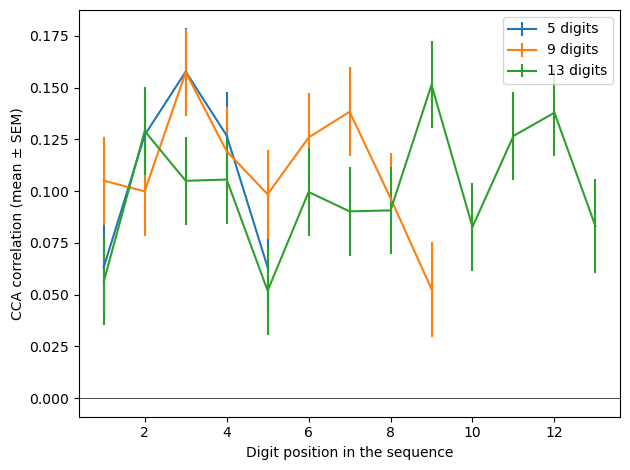

In [ ]:
DIG_LEN = 200
data = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\fast_slow_components\subject_level_cca_slow.csv")
best_shift_by_sub = data.groupby("subject")["lag_ms"].agg(lambda x: x.value_counts().index[0]).to_dict()
rows_trials = []
all_rows = []
win = slice(WIN_OFFSET1, -WIN_OFFSET2)

for subj in SUBJECTS:
    print(f"Subject {subj:03d}")
    best_shift = best_shift_by_sub.get(subj, 0) // 10  # convert ms to samples
    trials_memory, trials_control = split_trials_by_condition(load_all_trials(subj))
    channels_w,  weights  = load_weights(subj)
    
    if channels_w is None or weights is None:
        print(f"Missing or ambiguous weights for subject {subj:03d}, skipping subject.")
        continue
    
    for eeg_s, pupil_s, meta in iterate_trials(trials_memory, best_shift, win):
        n_digits = meta['load']
        for d in range(n_digits):
            w = slice(d*DIG_LEN, (d+1)*DIG_LEN)
            cv_eeg = np.dot(eeg_s, weights)
            cv_pupil = pupil_s.ravel()

        for d in range(n_digits):
            w = slice(d * DIG_LEN, (d + 1) * DIG_LEN)
            x, y = cv_eeg[w], cv_pupil[w]
            
            if x.size == 0 or y.size == 0:
                print("Empty slice:", meta['subject'], meta['epoch'], d)
                continue

            if not np.isfinite(x).all() or not np.isfinite(y).all():
                print("Non-finite values:", meta['subject'], meta['epoch'], d, "→", np.sum(~np.isfinite(x)), "bad in X;", np.sum(~np.isfinite(y)), "bad in Y")
                continue

            if np.std(x) == 0 or np.std(y) == 0:
                print("Const window:", meta['subject'], meta['epoch'], d, np.std(x), np.std(y))
                continue

            r = pearsonr(x, y)[0]
            #r = np.corrcoef(x, y)[0, 1]

            rows_trials.append({
                'subject': meta['subject'],
                'condition': meta['condition'],
                'load': meta['load'],
                'epoch': meta['epoch'],
                'lag_ms': best_shift * 10,  # convert samples to ms
                'digit_pos': d + 1,  # 1-based digit index
                'pupil': float(np.mean(y)),  # mean pupil size in this digit
                'F1': float(np.mean(eeg_s[w, 5])),  # mean EEG, F1 signal in this digit
                'eeg_component': float(np.mean(x)),  # mean CCA component in this digit
                'r': float(r),  # convert to plain float for JSON-ability
            })

        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)

df_sameW = pd.DataFrame(rows_trials)
grand = (df_sameW.query("condition == 'memory'")
           .groupby(['load','digit_pos'])['r']
           .agg(['mean','sem'])
           .reset_index())

for L in [5,9,13]:
    sub = grand[grand.load == L]
    plt.errorbar(sub.digit_pos, sub['mean'],
                 yerr=sub['sem'], label=f"{L} digits")
plt.axhline(0, c='k', lw=.5)
plt.xlabel("Digit position in the sequence")
plt.ylabel("CCA correlation (mean ± SEM)")
plt.legend(); plt.tight_layout()

pd.DataFrame(all_rows).to_csv("mem_trial_level_cca_slow.csv", index=False)
print("Finished - saved per-trial correlations with plain CCA.")

pd.DataFrame(rows_trials).to_csv("mem_digit_level_cca_slow.csv", index=False)
print("Finished - saved per-trial and digit correlations with plain CCA.")

In [ ]:
DIG_LEN = 200
data = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\fast_slow_components\subject_level_cca_slow.csv")
best_shift_by_sub = data.groupby("subject")["lag_ms"].agg(lambda x: x.value_counts().index[0]).to_dict()
rows_trials = []
all_rows = []
win = slice(WIN_OFFSET1, -WIN_OFFSET2)

for subj in SUBJECTS:
    best_shift = best_shift_by_sub.get(subj, 0) // 10  # convert ms to samples
    trials_memory, trials_control = split_trials_by_condition(load_all_trials(subj))
    channels_w,  weights  = load_weights(subj)
    
    if channels_w is None or weights is None:
        print(f"Missing or ambiguous weights for subject {subj:03d}, skipping subject.")
        continue
    
    for eeg_s, pupil_s, meta in iterate_trials(trials_control, best_shift, win):
        n_digits = meta['load']
        for d in range(n_digits):
            w = slice(d*DIG_LEN, (d+1)*DIG_LEN)
            cv_eeg = np.dot(eeg_s, weights)
            cv_pupil = pupil_s.ravel()

        for d in range(n_digits):
            w = slice(d * DIG_LEN, (d + 1) * DIG_LEN)
            x, y = cv_eeg[w], cv_pupil[w]
            
            if x.size == 0 or y.size == 0:
                print("Empty slice:", meta['subject'], meta['epoch'], d)
                continue

            if not np.isfinite(x).all() or not np.isfinite(y).all():
                print("Non-finite values:", meta['subject'], meta['epoch'], d, "→", np.sum(~np.isfinite(x)), "bad in X;", np.sum(~np.isfinite(y)), "bad in Y")
                continue

            if np.std(x) == 0 or np.std(y) == 0:
                print("Const window:", meta['subject'], meta['epoch'], d, np.std(x), np.std(y))
                continue

            r = pearsonr(x, y)[0]
            #r = np.corrcoef(x, y)[0, 1]

            rows_trials.append({
                'subject': meta['subject'],
                'condition': meta['condition'],
                'load': meta['load'],
                'epoch': meta['epoch'],
                'lag_ms': best_shift * 10,  # convert samples to ms
                'digit_pos': d + 1,  # 1-based digit index
                'pupil': float(np.mean(y)),  # mean pupil size in this digit
                'F1': float(np.mean(eeg_s[w, 5])),  # mean EEG, F1 signal in this digit
                'eeg_component': float(np.mean(x)),  # mean CCA component in this digit
                'r': float(r),  # convert to plain float for JSON-ability
            })

        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)

df_sameW = pd.DataFrame(rows_trials)
grand = (df_sameW.query("condition == 'control'")
           .groupby(['load','digit_pos'])['r']
           .agg(['mean','sem'])
           .reset_index())

for L in [5,9,13]:
    sub = grand[grand.load == L]
    plt.errorbar(sub.digit_pos, sub['mean'],
                 yerr=sub['sem'], label=f"{L} digits")
plt.axhline(0, c='k', lw=.5)
plt.xlabel("Digit position in the sequence")
plt.ylabel("CCA correlation (mean ± SEM)")
plt.legend(); plt.tight_layout()

pd.DataFrame(all_rows).to_csv("ctrl_trial_level_cca_slow.csv", index=False)
print("Finished - saved per-trial correlations with plain CCA.")

pd.DataFrame(rows_trials).to_csv("ctrl_digit_level_cca_slow.csv", index=False)
print("Finished - saved per-trial and digit correlations with plain CCA.")

## Comparing mem vs ctrl digits
However since we trained on memory it is biased that memory is significant

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats

# --------------------------
# Paths (edit if needed)
# --------------------------
mem_path  = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\classifier\mem_digit_level_cca_slow.csv")
ctrl_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\classifier\ctrl_digit_level_cca_slow.csv")

# --------------------------
# Load and keep needed cols
# --------------------------
cols = ["subject","condition","load","epoch","digit_pos","pupil","eeg","eeg_component","r"]
mem  = pd.read_csv(mem_path)
ctrl = pd.read_csv(ctrl_path)
mem  = mem[[c for c in cols if c in mem.columns]].copy()
ctrl = ctrl[[c for c in cols if c in ctrl.columns]].copy()

digit = 11

# Normalize keys/types
for df in (mem, ctrl):
    df["subject"]   = df["subject"].astype(str).str.strip()
    df["digit_pos"] = pd.to_numeric(df["digit_pos"], errors="coerce")
    for v in ["pupil","eeg","eeg_component","r"]:
        if v in df.columns:
            df[v] = pd.to_numeric(df[v], errors="coerce")

mem["condition"]  = "memory"
ctrl["condition"] = "control"

# --------------------------
# Filter to digit 9 only
# --------------------------
mem9  = mem.query(f"digit_pos == {digit}").copy()
ctrl9 = ctrl.query(f"digit_pos == {digit}").copy()

# --------------------------
# Mean per subject × condition
# (averaged across epochs (and loads if multiple),
#  since you asked for “take the mean for digit 5”)
# --------------------------
vars_ = ["pupil","eeg","eeg_component","r"]
mem_mean  = mem9.groupby(["subject","condition"], as_index=False)[vars_].mean(numeric_only=True)
ctrl_mean = ctrl9.groupby(["subject","condition"], as_index=False)[vars_].mean(numeric_only=True)

# Merge by subject; keep subjects that have BOTH conditions
m = (mem_mean.drop(columns="condition")
         .merge(ctrl_mean.drop(columns="condition"),
                on="subject", suffixes=("_mem","_ctrl")))

if m.empty:
    raise RuntimeError("No subjects have both memory and control data at digit_pos.")

# --------------------------
# Per-subject diffs
# --------------------------
per_subj = pd.DataFrame({"subject": m["subject"]})
for v in vars_:
    mem_v  = m[f"{v}_mem"].astype(float)
    ctrl_v = m[f"{v}_ctrl"].astype(float)
    diff   = mem_v - ctrl_v
    # relative difference vs control (percentage change if you *100)
    # handle |ctrl|=0 -> NaN
    rel    = diff / np.where(np.abs(ctrl_v) > 0, np.abs(ctrl_v), np.nan)

    per_subj[f"{v}_mean_mem"]  = mem_v
    per_subj[f"{v}_mean_ctrl"] = ctrl_v
    per_subj[f"{v}_diff"]      = diff
    per_subj[f"{v}_rel_diff"]  = rel

# Save per-subject table
out_path = Path(f"digit{digit}_per_subject_means_and_diffs.csv")
per_subj.to_csv(out_path, index=False)
print(f"Saved per-subject table: {out_path.resolve()}")

# --------------------------
# Group t-tests across subjects
# One-sample t-test on differences vs 0, one-sided (mean>0)
# --------------------------
def onesided_ttest_greater(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return {"n": len(x), "t": np.nan, "p_one_sided": np.nan}
    t, p_two = stats.ttest_1samp(x, popmean=0.0, nan_policy="omit")
    # one-sided for mean>0
    p_one = p_two/2 if t > 0 else 1 - p_two/2
    return {"n": len(x), "t": float(t), "p_one_sided": float(p_one)}

rows = []
for v in vars_:
    res_rel = onesided_ttest_greater(per_subj[f"{v}_rel_diff"])
    res_abs = onesided_ttest_greater(per_subj[f"{v}_diff"])
    rows.append({
        "variable": v,
        "RELDIFF_n": res_rel["n"],
        "RELDIFF_t": res_rel["t"],
        "RELDIFF_p_one_sided": res_rel["p_one_sided"],
        "RELDIFF_sig_0p05": (res_rel["p_one_sided"] < 0.05) if np.isfinite(res_rel["p_one_sided"]) else False,
        "ABSDIFF_n": res_abs["n"],
        "ABSDIFF_t": res_abs["t"],
        "ABSDIFF_p_one_sided": res_abs["p_one_sided"],
        "ABSDIFF_sig_0p05": (res_abs["p_one_sided"] < 0.05) if np.isfinite(res_abs["p_one_sided"]) else False,
        "mean_rel_diff": np.nanmean(per_subj[f"{v}_rel_diff"].to_numpy(dtype=float)),
        "mean_abs_diff": np.nanmean(per_subj[f"{v}_diff"].to_numpy(dtype=float)),
    })

summary = pd.DataFrame(rows)
sum_path = Path(f"digit{digit}_group_ttests_summary.csv")
summary.to_csv(sum_path, index=False)
print(f"Saved group summary: {sum_path.resolve()}")

print(f"\n=== Group t-tests (digit {digit}) ===")
print(summary.to_string(index=False))


## ANOVA for difference across digits within subjects (memory condition)

In [1]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\classifier\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means') ---
results = []
pairs = []
for v in vars_:
    long = means[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

     variable  n_subjects  n_digits        F        p-unc    p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          56        13 9.154111 1.910150e-16 2.458538e-05       False  3.290200e-08       875.366128              77 1.047502e-134 0.229503     NaN
           F1          56        13 9.536200 3.193514e-17 3.583898e-09       False  1.901094e-04       435.297464              77  5.768017e-51 0.467072     NaN
eeg_component          56        13 6.460150 6.068125e-11 1.284805e-04       False  1.012335e-02       233.345363              77  1.817970e-17 0.299171     NaN
            r          56        13 1.833877 3.969519e-02 1.070815e-01       False  2.302024e-03       308.591241              77  3.412349e-29 0.412800     NaN

Pairwise post-hoc tests:
     variable  A  B         T  dof        p-unc       p-corr p-adjust     cohen
        pupil  1  2  0.966893 55.0 3.378300e-01 4.053960e-01   fdr_bh  0.088698
        p

In [8]:
import pandas as pd
from pathlib import Path

# --- Path to your file ---
in_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\classifier\pairwise_memory_only.csv")

# --- Read ---
df = pd.read_csv(in_path)

# Safety: normalize column name just in case of stray spaces/casing
df.columns = [c.strip() for c in df.columns]

# --- Filter p-corr < 0.05 ---
sig = df[df['p-corr'] < 0.05].copy().sort_values(['variable','A','B'])

print("Significant pairs (p-corr < 0.05):")
if sig.empty:
    print("None.")
else:
    # Show a compact view
    print(sig[['variable','A','B','T','dof','cohen','p-unc','p-corr']].to_string(index=False))

# --- Save filtered CSV ---
out_csv = in_path.with_name(in_path.stem + "_significant_two.csv")
sig.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")


Significant pairs (p-corr < 0.05):
     variable  A  B         T  dof     cohen        p-unc       p-corr
           F1  1  3 -2.749747 55.0 -0.484659 8.055185e-03 1.911534e-02
           F1  1  4 -5.233135 55.0 -1.190282 2.684212e-06 2.093685e-05
           F1  1  5 -6.105805 55.0 -1.378716 1.084897e-07 3.546702e-06
           F1  1  6 -5.956343 55.0 -1.269951 1.892311e-07 3.546702e-06
           F1  1  7 -6.003274 55.0 -1.320297 1.589392e-07 3.546702e-06
           F1  1  8 -5.906900 55.0 -1.296314 2.273527e-07 3.546702e-06
           F1  1  9 -4.493423 55.0 -1.008067 3.647103e-05 2.031957e-04
           F1  1 10 -3.715720 55.0 -0.741393 4.756572e-04 1.952698e-03
           F1  1 11 -3.276952 55.0 -0.607422 1.820930e-03 5.918022e-03
           F1  1 12 -4.035570 55.0 -0.806530 1.698095e-04 7.791260e-04
           F1  1 13 -3.441282 55.0 -0.703926 1.112803e-03 3.945392e-03
           F1  2  3 -2.381941 55.0 -0.323886 2.070764e-02 4.250516e-02
           F1  2  4 -5.381999 55.0 -1.1204

In [ ]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\classifier\mem_digit_level_cca_slow.csv")
mem5 = mem[mem["load"] == 5]
mem5["subject"] = mem5["subject"].astype(str).str.strip()
mem5["digit_pos"] = pd.to_numeric(mem5["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem5[v] = pd.to_numeric(mem5[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem5.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means') ---
results = []
pairs = []
for v in vars_:
    long = means[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory5_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory5_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

C:\Users\cdd\AppData\Local\Temp\ipykernel_34896\2625573268.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem5["subject"] = mem5["subject"].astype(str).str.strip()
C:\Users\cdd\AppData\Local\Temp\ipykernel_34896\2625573268.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem5["digit_pos"] = pd.to_numeric(mem5["digit_pos"], errors="coerce")
C:\Users\cdd\AppData\Local\Temp\ipykernel_34896\2625573268.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

     variable  n_subjects  n_digits         F        p-unc    p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          57         5  3.188248 1.425038e-02 5.205978e-02       False      0.072061       143.128705               9  2.643559e-26 0.437491     NaN
           F1          57         5 17.621340 1.370256e-12 1.290535e-07       False      0.121429       114.733402               9  1.732719e-20 0.522449     NaN
eeg_component          57         5  5.065401 6.315816e-04 8.490105e-03       False      0.083994       134.790633               9  1.371101e-24 0.484313     NaN
            r          57         5  5.326743 4.081261e-04          NaN        True      0.748654        15.752449               9  7.235567e-02 0.884106     NaN

Pairwise post-hoc tests:
     variable A B         T  dof    p-unc   p-corr p-adjust     cohen
        pupil 1 2  1.072892 56.0 0.287921 0.411316   fdr_bh  0.148964
        pupil 1 3  3.024

In [ ]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\classifier\mem_digit_level_cca_slow.csv")
mem9 = mem[mem["load"] == 9]
mem9["subject"] = mem9["subject"].astype(str).str.strip()
mem9["digit_pos"] = pd.to_numeric(mem9["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem9[v] = pd.to_numeric(mem9[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem9.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means') ---
results = []
pairs = []
for v in vars_:
    long = means[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory9_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory9_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

C:\Users\cdd\AppData\Local\Temp\ipykernel_19028\2581817953.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem9["subject"] = mem9["subject"].astype(str).str.strip()
C:\Users\cdd\AppData\Local\Temp\ipykernel_19028\2581817953.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem9["digit_pos"] = pd.to_numeric(mem9["digit_pos"], errors="coerce")
C:\Users\cdd\AppData\Local\Temp\ipykernel_19028\2581817953.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\classifier\mem_digit_level_cca_slow.csv")
mem13 = mem[mem["load"] == 13]
mem13["subject"] = mem13["subject"].astype(str).str.strip()
mem13["digit_pos"] = pd.to_numeric(mem13["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem13[v] = pd.to_numeric(mem13[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem13.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means') ---
results = []
pairs = []
for v in vars_:
    long = means[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory13_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory13_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

C:\Users\cdd\AppData\Local\Temp\ipykernel_19028\2397002838.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem13["subject"] = mem13["subject"].astype(str).str.strip()
C:\Users\cdd\AppData\Local\Temp\ipykernel_19028\2397002838.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem13["digit_pos"] = pd.to_numeric(mem13["digit_pos"], errors="coerce")
C:\Users\cdd\AppData\Local\Temp\ipykernel_19028\2397002838.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


     variable  n_subjects  n_digits        F        p-unc  p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          56        13 7.332715 1.000062e-12   0.000308       False  4.042697e-08       864.902029              77 1.223865e-132 0.213328     NaN
           F1          56        13 5.003839 5.431531e-08   0.000164       False  4.567220e-05       507.751779              77  4.140860e-64 0.433755     NaN
eeg_component          56        13 3.582603 3.379480e-05   0.007411       False  3.300254e-03       290.290533              77  3.117042e-26 0.334289     NaN
            r          56        13 1.979335 2.369126e-02   0.071431       False  5.909272e-03       260.695125              77  1.392493e-21 0.478165     NaN

Pairwise post-hoc tests:
     variable  A  B         T  dof        p-unc   p-corr p-adjust     cohen
        pupil  1  2 -1.153190 55.0 2.538196e-01 0.347332   fdr_bh -0.076431
        pupil  1  3  0.7098

In [10]:
import pandas as pd
from pathlib import Path

# --- Path to your file ---
in_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\classifier\pairwise_memory13_only.csv")

# --- Read ---
df = pd.read_csv(in_path)

# Safety: normalize column name just in case of stray spaces/casing
df.columns = [c.strip() for c in df.columns]

# --- Filter p-corr < 0.05 ---
sig = df[df['p-corr'] < 0.05].copy().sort_values(['variable','A','B'])

print("Significant pairs (p-corr < 0.05):")
if sig.empty:
    print("None.")
else:
    # Show a compact view
    print(sig[['variable','A','B','T','dof','cohen','p-unc','p-corr']].to_string(index=False))

# --- Save filtered CSV ---
out_csv = in_path.with_name(in_path.stem + "_significant.csv")
sig.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")


Significant pairs (p-corr < 0.05):
variable  A  B         T  dof     cohen        p-unc   p-corr
      F1  1  5 -2.758786 55.0 -0.534519 7.862464e-03 0.030664
      F1  1  6 -3.390867 55.0 -0.730867 1.296061e-03 0.012637
      F1  1  7 -3.336590 55.0 -0.772822 1.525185e-03 0.013218
      F1  1  8 -2.984882 55.0 -0.649382 4.226970e-03 0.019821
      F1  2  6 -3.262361 55.0 -0.629978 1.901118e-03 0.013851
      F1  2  7 -3.099684 55.0 -0.668996 3.051769e-03 0.018765
      F1  2  8 -2.653292 55.0 -0.551459 1.039943e-02 0.036871
      F1  3  4 -2.939923 55.0 -0.476659 4.792933e-03 0.020769
      F1  3  5 -3.963637 55.0 -0.813019 2.148132e-04 0.003351
      F1  3  6 -5.196650 55.0 -1.127907 3.061653e-06 0.000119
      F1  3  7 -5.658447 55.0 -1.176493 5.693258e-07 0.000044
      F1  3  8 -4.978199 55.0 -1.051064 6.693104e-06 0.000174
      F1  3  9 -4.098855 55.0 -0.820129 1.378662e-04 0.002688
      F1  3 10 -3.820906 55.0 -0.733830 3.404992e-04 0.004426
      F1  3 11 -2.977126 55.0 -0.60

In [2]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
bin_map = {
    "early": {1,2,3},
    "mid":   {7,8,9},
    "late":  {11,12,13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned = means.copy()
binned["bin3"] = binned["digit_pos"].map(digit_bin)
binned = binned.dropna(subset=["bin3"])


In [11]:
# --- INVERTED-U: within-subject bin tests using SciPy (no DataFrame indexing gotchas) ---
import numpy as np
from scipy.stats import ttest_rel

def within_subject_bin_tests(df, v):
    # subject-level means per bin (paired design)
    wide = (df[["subject","bin3", v]]
            .dropna()
            .groupby(["subject","bin3"], as_index=False)[v].mean()
            .pivot(index="subject", columns="bin3", values=v))

    # keep subjects with all three bins
    need = {"early","mid","late"}
    if not need.issubset(set(wide.columns)):
        # add any missing columns so .dropna works cleanly
        for col in need - set(wide.columns):
            wide[col] = np.nan
    wide = wide.dropna(subset=["early","mid","late"], how="any")

    n = wide.shape[0]
    if n < 5:
        return None

    # paired arrays
    e = wide["early"].to_numpy(dtype=float)
    m = wide["mid"].to_numpy(dtype=float)
    l = wide["late"].to_numpy(dtype=float)

    # one-sided paired t-tests: H1 mid > early, mid > late
    t_me, p_me = ttest_rel(m, e, alternative="greater")
    t_ml, p_ml = ttest_rel(m, l, alternative="greater")

    # Cohen's dz for paired differences
    def cohen_dz(a, b):
        d = a - b
        return d.mean() / d.std(ddof=1)

    return {
        "n_subjects": int(n),
        "mid>early_t": float(t_me), "mid>early_p": float(p_me), "dz_me": float(cohen_dz(m, e)),
        "mid>late_t":  float(t_ml), "mid>late_p":  float(p_ml), "dz_ml": float(cohen_dz(m, l)),
        "mean(early)": float(e.mean()), "mean(mid)": float(m.mean()), "mean(late)": float(l.mean()),
    }

bin_tests = []
for v in vars_:
    res = within_subject_bin_tests(binned, v)
    if res:
        res["variable"] = v
        bin_tests.append(res)

bin_df = pd.DataFrame(bin_tests)
bin_df.to_csv("invertedU_bin_tests.csv", index=False)
print(bin_df.to_string(index=False))


 n_subjects  mid>early_t  mid>early_p     dz_me  mid>late_t  mid>late_p    dz_ml  mean(early)  mean(mid)  mean(late)      variable
         56     4.151920 5.781808e-05  0.554824    4.634391    0.000011 0.619297    -0.077381   0.231215   -0.013539         pupil
         56     5.557586 4.122504e-07  0.742664    3.515853    0.000443 0.469826    -0.075140   0.126095    0.021852            F1
         56     3.644164 2.977720e-04  0.486972    1.931839    0.029269 0.258153    -0.062867   0.077328    0.030310 eeg_component
         56    -0.794756 7.849142e-01 -0.106204    0.445446    0.328873 0.059525     0.131192   0.119475    0.107316             r


In [29]:
import statsmodels.formula.api as smf
import numpy as np

df = means[["subject","digit_pos","pupil","F1","eeg_component", "r"]].dropna().copy()

# z-score helps numerics, not required
for c in ["pupil","F1","eeg_component"]:
    mu, sd = df[c].mean(), df[c].std(ddof=1)
    if sd > 0: df[c] = (df[c] - mu)/sd

# OLS with subject dummies; cluster SEs by subject
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_full.summary().tables[1])

# Test EEG coefficient (H0: eeg_component = 0; H1: > 0)
print("\nWald test for EEG > 0:")
print(m_full.t_test("eeg_component = 0"))
# For one-sided p (greater), halve the two-sided p if coef > 0:
coef = m_full.params["eeg_component"]
p_two = float(m_full.t_test("eeg_component = 0").pvalue)
p_one = p_two/2 if coef > 0 else 1 - p_two/2
print(f"EEG coef = {coef:.3f}, one-sided p = {p_one:.3g}")


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 7.0828      0.206     34.359      0.000       6.679       7.487
C(subject)[T.sub-034]    -0.1056      0.246     -0.429      0.668      -0.588       0.377
C(subject)[T.sub-035]     0.3786      0.523      0.723      0.470      -0.647       1.404
C(subject)[T.sub-036]     0.1141      0.101      1.133      0.257      -0.083       0.311
C(subject)[T.sub-038]     0.3397      0.113      3.012      0.003       0.119       0.561
C(subject)[T.sub-039]     0.1847      0.284      0.650      0.516      -0.372       0.742
C(subject)[T.sub-040]    -0.2126      0.394     -0.540      0.589      -0.985       0.559
C(subject)[T.sub-041]     0.3845      0.168      2.288      0.022       0.055       0.714
C(subject)[T.sub-042]    -0.1051      0.102     -1.026      0.305      -0.306       0.096
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [30]:
# Test EEG coefficient (H0: eeg_component = 0; H1: > 0)
print("\nWald test for EEG > 0:")
print(m_full.t_test("r = 0"))
# For one-sided p (greater), halve the two-sided p if coef > 0:
coef = m_full.params["r"]
p_two = float(m_full.t_test("r = 0").pvalue)
p_one = p_two/2 if coef > 0 else 1 - p_two/2
print(f"r coef = {coef:.3f}, one-sided p = {p_one:.3g}")


Wald test for EEG > 0:
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -1.5276      1.027     -1.487      0.137      -3.541       0.486
r coef = -1.528, one-sided p = 0.932


In [31]:
print("R² =", m_full.rsquared, " |  Adj. R² =", m_full.rsquared_adj)
# Subject-demean y and X (within transformation)
tmp = df.copy()
for col in ["digit_pos","pupil","F1","eeg_component"]:
    tmp[col] = tmp[col] - tmp.groupby("subject")[col].transform("mean")

wmod = smf.ols("digit_pos ~ pupil + F1 + eeg_component - 1", data=tmp).fit()
# (- 1 removes intercept because demeaned variables have mean ~ 0)
print("Within-subject R² =", wmod.rsquared)


R² = 0.07393487697863765  |  Adj. R² = -0.008749509005412381
Within-subject R² = 0.06210941260283065


In [32]:
m_red = smf.ols("digit_pos ~ pupil + F1 + C(subject)", data=df).fit()
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r +C(subject)", data=df).fit()

SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_full.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) =", partial_R2_eeg)


Partial R² (EEG | F1,pupil) = 0.03767563240319339


In [33]:
import statsmodels.formula.api as smf
import numpy as np


# OLS with subject dummies; cluster SEs by subject
m_not_eeg = smf.ols("digit_pos ~ pupil + F1 + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_not_eeg.summary().tables[1])

print("R² =", m_not_eeg.rsquared, " |  Adj. R² =", m_full.rsquared_adj)
# Subject-demean y and X (within transformation)
tmp = df.copy()
for col in ["digit_pos","pupil","F1"]:
    tmp[col] = tmp[col] - tmp.groupby("subject")[col].transform("mean")

wmod = smf.ols("digit_pos ~ pupil + F1 - 1", data=tmp).fit()
# (- 1 removes intercept because demeaned variables have mean ~ 0)
print("Within-subject R² =", wmod.rsquared)



                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 7.2193      0.142     50.720      0.000       6.940       7.498
C(subject)[T.sub-034]    -0.3787      0.231     -1.639      0.101      -0.831       0.074
C(subject)[T.sub-035]    -0.2420      0.469     -0.516      0.606      -1.161       0.677
C(subject)[T.sub-036]    -0.0148      0.057     -0.259      0.796      -0.127       0.098
C(subject)[T.sub-038]    -0.0036      0.059     -0.061      0.952      -0.119       0.112
C(subject)[T.sub-039]    -0.3771      0.223     -1.688      0.091      -0.815       0.061
C(subject)[T.sub-040]    -0.5316      0.360     -1.475      0.140      -1.238       0.175
C(subject)[T.sub-041]     0.1029      0.132      0.781      0.435      -0.156       0.361
C(subject)[T.sub-042]    -0.2388      0.098     -2.447      0.014      -0.430      -0.048
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 58, but rank is 2
  warnings.warn('covariance of constraints does not have full '


In [1]:
import pandas as pd, numpy as np, statsmodels.api as sm, statsmodels.formula.api as smf

# 1) Load raw trial-level data
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\classifier\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
# mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

# 3) OLS with subject fixed effects and cluster-robust SEs by subject
mem["subtrial"] = mem["subject"].astype(str) + "|" + mem["epoch"].astype(str)
m_trial = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + eeg_wt", data=mem) \
             .fit(cov_type="cluster", cov_kwds={"groups": mem["subtrial"]})


print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

# 4) Unique contribution of EEG at trial-level: partial R² (EEG | pupil,F1)
m_red = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + C(subject)", data=mem).fit()
SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_trial.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) at trial-level =", partial_R2_eeg)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5.421e-19   3.18e-18      0.171      0.865   -5.69e-18    6.77e-18
pupil_wt       0.1346      0.032      4.247      0.000       0.072       0.197
F1_wt          0.2184      0.022      9.817      0.000       0.175       0.262
eeg_wt         0.1495      0.022      6.746      0.000       0.106       0.193
Within-trial R² = 0.011691438178870639
Partial R² (EEG | F1,pupil) at trial-level = 0.002231416970546876


In [37]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned.dropna(subset=["subject","bin3","F1","pupil","eeg_component","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1","pupil"],
    "F1+pupil+EEG":  ["F1","pupil","eeg_component"],
    "EEG only":      ["eeg_component"],
    "F1 only":       ["F1"],
    "pupil only":    ["pupil"],
    "All 4":         ["F1","pupil","eeg_component","r"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                    features  accuracy  macro_f1
       All 4 F1, pupil, eeg_component, r  0.495069  0.492057
F1+pupil+EEG    F1, pupil, eeg_component  0.489152  0.483574
    F1+pupil                   F1, pupil  0.477318  0.468702
     F1 only                          F1  0.475345  0.458387
    EEG only               eeg_component  0.418146  0.399692
  pupil only                       pupil  0.414201  0.397251

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.516     0.561     0.538       171
        late      0.331     0.268     0.296       168
         mid      0.546     0.601     0.572       168

    accuracy                          0.477       507
   macro avg      0.464     0.477     0.469       507
weighted avg      0.465     0.477     0.469       507

Normalized confusion matrix (rows sum to 1):
            pred_early  pred_late  pred_mid
true_earl

In [110]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\classifier\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

#mem = mem[mem["load"] == 13]

bin_map = {
    "early": {1, 2, 3},
    "mid":   {7, 8, 9},
    "late":  {11, 12, 13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned_mem = mem.copy()
binned_mem["bin3"] = binned_mem["digit_pos"].map(digit_bin)
binned_mem = binned_mem.dropna(subset=["bin3"]).drop(columns={"condition"})


In [112]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned_mem.dropna(subset=["subject","bin3","F1_wt","pupil_wt","eeg_wt","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.412473  0.378394
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.412170  0.377995
    F1+pupil            F1_wt, pupil_wt  0.409860  0.373367
   pupil+EEG           pupil_wt, eeg_wt  0.387027  0.361843
     F1 only                      F1_wt  0.446098  0.359072
  pupil only                   pupil_wt  0.378129  0.343509
    EEG only                     eeg_wt  0.432996  0.341594

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.557     0.388     0.457     13290
        late      0.175     0.232     0.200      4386
         mid      0.410     0.533     0.463      8733

    accuracy                          0.410     26409
   macro avg      0.381     0.384     0.373     26409
weighted avg      0.445     0.410     0.416     26409

Normalized confusion matrix (rows sum to 1):


## RECALL ACCURACY

In [90]:
import pandas as pd
from pathlib import Path
from scipy import stats

corr = (pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\classifier\mem_digit_level_cca_slow.csv")
          .assign(                       # extract trial #, then +1 to match *.tsv
              trial=lambda d:
                  d.epoch.str.extract(r"trial_(\d+)\.csv")
                    .astype(int).squeeze()
                    + 1                 # 0-based → 1-based
          ))
#corr = corr[corr["load"] == 9]
BEH_DIR    = Path(r"C:\Users\cdd\Documents\Uni\Special_course\ds003838-download")

In [91]:
grp = corr.groupby(["subject","epoch"])
corr["digit_pos_wt"] = corr["digit_pos"] - grp["digit_pos"].transform("mean")
corr["pupil_wt"]     = corr["pupil"]     - grp["pupil"].transform("mean")
corr["F1_wt"]        = corr["F1"]        - grp["F1"].transform("mean")
corr["r_wt"]        = corr["r"]          - grp["r"].transform("mean")
corr["eeg_wt"]       = corr["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = corr[c].mean(), corr[c].std(ddof=1)
    if sd > 0: corr[c] = (corr[c] - mu)/sd

In [81]:
def explode_triggers(df_beh):
    out_frames = []
    for _, row in df_beh.iterrows():
        trig = row["triggerCorrect"].strip()
        out_frames.append(pd.DataFrame({
            "trial"     : row["trial"],
            "digit_pos" : range(1, len(trig) + 1),   # 1, 2, …
            "recalled"  : [int(c) for c in trig]      # 0 / 1
        }))
    return pd.concat(out_frames, ignore_index=True)


In [92]:
subject_dfs = []      # collect for an optional grand-average
stats_per_sub = []    # store per-subject t-tests

for sub in corr["subject"].unique():
    # --- Behaviour ------------------------------------------------------
    beh_path = (BEH_DIR / sub / "beh" / f"{sub}_task-memory_beh.tsv")
    beh_raw  = pd.read_csv(beh_path, sep="\t", usecols=["trial", "triggerCorrect"], dtype = {"triggerCorrect": str})
    beh      = explode_triggers(beh_raw)

    # --- Merge ----------------------------------------------------------
    merged = corr.query("subject == @sub").merge(
                 beh, on=["trial", "digit_pos"], how="inner")

    # --- Stats ----------------------------------------------------------
    rec  = merged.loc[merged.recalled == 1, "r"]
    miss = merged.loc[merged.recalled == 0, "r"]

    t, p = stats.ttest_ind(rec, miss, equal_var=False)
    stats_per_sub.append(
        {"subject": sub,
         "mean_r_recalled": rec.mean(),
         "mean_r_missed"  : miss.mean(),
         "t" : t, "p" : p, "n_recalled": len(rec), "n_missed": len(miss)}
    )

    merged["subject"] = sub
    subject_dfs.append(merged)


In [94]:
subject_df = pd.concat(subject_dfs, ignore_index=True, sort=False)

In [93]:
print(f"sub {sub}:  n_raecalled = {len(rec)},  var = {rec.var(ddof=1):.3g}, mean = {rec.mean():.3g} ")
print(f"sub {sub}:  n_missed   = {len(miss)}, var = {miss.var(ddof=1):.3g}, mean = {miss.mean():.3g}")


sub sub-098:  n_raecalled = 173,  var = 0.647, mean = 0.178 
sub sub-098:  n_missed   = 214, var = 0.663, mean = 0.22


In [95]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df_corr = subject_df.dropna(subset=["subject","recalled","F1_wt","pupil_wt","eeg_wt","r_wt"]).copy()
df_corr["recalled"] = df_corr["recalled"].astype("category")
y = df_corr["recalled"].values
groups = df_corr["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df_corr[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df_corr = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df_corr.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df_corr = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df_corr.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
  pupil only                   pupil_wt  0.521442  0.519959
    F1+pupil            F1_wt, pupil_wt  0.519071  0.518295
   pupil+EEG           pupil_wt, eeg_wt  0.517582  0.516263
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.515236  0.514669
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.515110  0.514549
    EEG only                     eeg_wt  0.512209  0.511320
     F1 only                      F1_wt  0.503405  0.503372

--- F1+pupil ---
              precision    recall  f1-score   support

           0      0.565     0.513     0.538     21615
           1      0.474     0.527     0.499     18027

    accuracy                          0.519     39642
   macro avg      0.520     0.520     0.518     39642
weighted avg      0.524     0.519     0.520     39642

Normalized confusion matrix (rows sum to 1):
        pred_0  pred_1
true_0   0.513   0.487
true_1  